# Preprocessing Pipeline

**Docker image**: `ml4t`

**Chapter 7: Defining the Learning Task**
**Section Reference**: 7.1 - Data Preprocessing and Encodings

## Purpose

This notebook implements **hands-on cleaning** for datasets that need it, plus
demonstrates **split-aware preprocessing** mechanics. The key teaching artifact
is the `SplitAwarePreprocessor` class that prevents lookahead bias.

## Learning Objectives

1. Apply domain filters, spike detection, and winsorization
2. Understand why preprocessing must be fit on training data only
3. Implement a reusable `SplitAwarePreprocessor` class
4. Clean US Equities and ETF datasets with audit trails
5. Perform cross-dataset alignment (different frequencies)

## Book Reference

Section 7.1 emphasizes that **preprocessing choices affect model validity**.
Fitting scalers or encoders on full data introduces lookahead bias.

## Prerequisites

- `01_data_quality_diagnostics` — establishes the baseline coverage and
  outlier counts that motivate each cleaning step here.
- Familiarity with leakage-aware splitting (Chapter 6 §6.3).
- Polars expressions, Jupytext percent-format notebooks.

## Data Contract

- **Input**: Raw datasets from data loaders
- **Output**: In-memory cleaned DataFrames (teaching demonstration, not persisted)

In [1]:
"""Preprocessing Pipeline - Clean datasets with split-aware processing."""

from __future__ import annotations

import pickle
import tempfile
import warnings
from collections.abc import Callable
from dataclasses import dataclass, field
from datetime import datetime
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import display
from ml4t.engineer.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from data import (
    load_crypto_perps,
    load_crypto_premium,
    load_etfs,
    load_firm_characteristics,
    load_us_equities,
)
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

.venv/lib/python3.14/site-packages/ml4t/engineer/features/ml/__init__.py:9: UserWarning: Feature 'cyclical_encode': lookback=0 but has period/window parameter. Consider using lookback='period' or specifying the actual lookback.
  from ml4t.engineer.features.ml.cyclical_encode import *  # noqa: F403


In [2]:
# Production defaults
SEED = 42
US_EQUITIES_START_DATE = "1970-01-01"
ETF_START_DATE = "2015-01-01"
CRYPTO_START_DATE = "2021-01-01T00:00:00+00:00"
FIRM_CHARACTERISTICS_START_DATE = "1990-01-01"

In [3]:
set_global_seeds(SEED)

In [4]:
def ensure_symbol_alias(df: pl.DataFrame) -> pl.DataFrame:
    """Expose canonical asset identifiers under the symbol name when needed."""
    if "asset" in df.columns and "symbol" not in df.columns:
        return df.with_columns(pl.col("asset").alias("symbol"))
    return df

In [5]:
def filter_from_start(df: pl.DataFrame, time_col: str, start_value: str) -> pl.DataFrame:
    """Apply a start-date filter without timezone/unit mismatches."""
    start_date = datetime.fromisoformat(start_value).date()
    dtype = df.schema[time_col]
    if dtype == pl.Date:
        return df.filter(pl.col(time_col) >= pl.lit(start_date).cast(pl.Date))
    return df.filter(pl.col(time_col).dt.date() >= pl.lit(start_date).cast(pl.Date))

## 1. Preprocessing Utilities

Reusable functions for common data cleaning operations.

### 1.1 Remove Duplicates

Handles exact duplicates and near-duplicates with configurable strategy.

In [6]:
def remove_duplicates(
    df: pl.DataFrame,
    key_cols: list[str],
    strategy: Literal["keep_first", "keep_last", "drop_all"] = "keep_last",
) -> tuple[pl.DataFrame, int]:
    """Remove duplicate rows based on key columns.

    Args:
        df: Input DataFrame
        key_cols: Columns that define uniqueness
        strategy: How to handle duplicates
            - keep_first: Keep first occurrence
            - keep_last: Keep last occurrence
            - drop_all: Remove all duplicates

    Returns:
        Tuple of (cleaned DataFrame, number of rows removed)
    """
    original_len = len(df)

    if strategy == "keep_first":
        result = df.unique(subset=key_cols, keep="first")
    elif strategy == "keep_last":
        result = df.unique(subset=key_cols, keep="last")
    else:  # drop_all
        # Count occurrences and keep only unique rows
        counts = df.group_by(key_cols).len()
        unique_keys = counts.filter(pl.col("len") == 1).drop("len")
        result = df.join(unique_keys, on=key_cols, how="inner")

    n_removed = original_len - len(result)
    return result, n_removed

### 1.2 Fill Expected Gaps

Distinguishes between expected gaps (weekends, holidays) and unexpected gaps.

In [7]:
def fill_expected_gaps(
    df: pl.DataFrame,
    time_col: str,
    symbol_col: str | None,
    method: Literal["ffill", "interpolate", "flag_only"] = "flag_only",
    max_gap_days: int = 5,
) -> pl.DataFrame:
    """Handle gaps in time series data.

    Args:
        df: Input DataFrame
        time_col: Time column name
        symbol_col: Symbol column (None for single asset)
        method: How to handle gaps
            - ffill: Forward fill
            - interpolate: Linear interpolation
            - flag_only: Add flag column without filling
        max_gap_days: Maximum gap to fill (longer gaps are flagged)

    Returns:
        DataFrame with gaps handled
    """
    # Add gap flag column
    if symbol_col and symbol_col in df.columns:
        result = df.sort([symbol_col, time_col]).with_columns(
            prev_date=pl.col(time_col).shift(1).over(symbol_col),
        )
    else:
        result = df.sort(time_col).with_columns(
            prev_date=pl.col(time_col).shift(1),
        )

    # Calculate gap in days
    result = result.with_columns(gap_days=(pl.col(time_col) - pl.col("prev_date")).dt.total_days())

    # Flag unexpected gaps (>1 day for daily, accounting for weekends)
    result = result.with_columns(
        is_gap=(pl.col("gap_days") > max_gap_days) & pl.col("prev_date").is_not_null()
    )

    # Clean up temporary columns
    result = result.drop(["prev_date", "gap_days"])

    return result

### 1.3 Apply Domain Filters

Remove rows with impossible values (negative prices, zero volume, etc.)

In [8]:
def apply_domain_filters(
    df: pl.DataFrame,
    rules: dict[str, Callable[[pl.Expr], pl.Expr]],
) -> tuple[pl.DataFrame, dict[str, int]]:
    """Apply domain validation rules and filter invalid rows.

    Args:
        df: Input DataFrame
        rules: Dictionary of {rule_name: filter_expression}
               Expression should return True for rows to KEEP

    Returns:
        Tuple of (filtered DataFrame, counts of removed rows per rule)

    Example:
        >>> rules = {
        ...     "positive_close": lambda c: pl.col("close") > 0,
        ...     "non_negative_volume": lambda c: pl.col("volume") >= 0,
        ... }
        >>> clean_df, removed = apply_domain_filters(df, rules)
    """
    removed_counts = {}
    result = df

    for rule_name, filter_fn in rules.items():
        pre_len = len(result)
        result = result.filter(filter_fn(None))
        removed_counts[rule_name] = pre_len - len(result)

    return result, removed_counts

### 1.4 Spike Filter

Detect and flag single-bar price reversals (potential data errors).

In [9]:
def spike_filter(
    df: pl.DataFrame,
    price_col: str = "close",
    threshold: float = 0.5,
    symbol_col: str | None = "symbol",
    time_col: str = "timestamp",
    action: Literal["flag", "remove", "replace"] = "flag",
) -> pl.DataFrame:
    """Detect and handle price spikes (single-bar reversals).

    A spike is defined as:
    - Return > threshold (e.g., 50% up)
    - Followed by return < -threshold/(1+threshold) (reverting back)

    Args:
        df: Input DataFrame
        price_col: Price column to check
        threshold: Minimum return to be considered a spike
        symbol_col: Symbol column for panel data
        time_col: Time column for sorting
        action: How to handle spikes
            - flag: Add is_spike column
            - remove: Remove spike rows
            - replace: Replace spike with interpolated value

    Returns:
        DataFrame with spikes handled
    """
    # Calculate returns
    if symbol_col and symbol_col in df.columns:
        result = df.sort([symbol_col, time_col]).with_columns(
            ret=pl.col(price_col).pct_change().over(symbol_col),
            ret_next=pl.col(price_col).pct_change().shift(-1).over(symbol_col),
        )
    else:
        result = df.sort(time_col).with_columns(
            ret=pl.col(price_col).pct_change(),
            ret_next=pl.col(price_col).pct_change().shift(-1),
        )

    # Detect spikes (sharp move followed by reversion)
    reversion_threshold = -threshold / (1 + threshold)
    result = result.with_columns(
        is_spike=((pl.col("ret") > threshold) & (pl.col("ret_next") < reversion_threshold))
        | ((pl.col("ret") < -threshold / (1 + threshold)) & (pl.col("ret_next") > threshold))
    )

    if action == "remove":
        result = result.filter(~pl.col("is_spike"))
    elif action == "replace":
        # Replace with geometric mean of before and after
        if symbol_col and symbol_col in df.columns:
            result = result.with_columns(
                pl.when(pl.col("is_spike"))
                .then(
                    (
                        pl.col(price_col).shift(1).over(symbol_col)
                        * pl.col(price_col).shift(-1).over(symbol_col)
                    ).sqrt()
                )
                .otherwise(pl.col(price_col))
                .alias(price_col)
            )
        else:
            result = result.with_columns(
                pl.when(pl.col("is_spike"))
                .then((pl.col(price_col).shift(1) * pl.col(price_col).shift(-1)).sqrt())
                .otherwise(pl.col(price_col))
                .alias(price_col)
            )

    # Clean up temporary columns
    result = result.drop(["ret", "ret_next"])

    return result

### 1.5 Winsorize Panel

Clip extreme values at percentile thresholds, respecting panel structure.

In [10]:
def winsorize_panel(
    df: pl.DataFrame,
    fields: list[str],
    limits: tuple[float, float] = (0.01, 0.99),
    by_period: bool = True,
    period_col: str = "timestamp",
) -> pl.DataFrame:
    """Winsorize (clip) extreme values at percentile bounds.

    Args:
        df: Input DataFrame
        fields: Columns to winsorize
        limits: (lower_percentile, upper_percentile) bounds
        by_period: If True, compute bounds per time period (cross-sectional)
        period_col: Column to group by for cross-sectional winsorization

    Returns:
        DataFrame with winsorized values
    """
    result = df

    for col_name in fields:
        if col_name not in df.columns:
            continue

        if by_period:
            # Cross-sectional winsorization (per date)
            bounds = df.group_by(period_col).agg(
                [
                    pl.col(col_name).quantile(limits[0]).alias("lower"),
                    pl.col(col_name).quantile(limits[1]).alias("upper"),
                ]
            )
            result = result.join(bounds, on=period_col, how="left")
            result = result.with_columns(
                pl.when(pl.col(col_name) < pl.col("lower"))
                .then(pl.col("lower"))
                .when(pl.col(col_name) > pl.col("upper"))
                .then(pl.col("upper"))
                .otherwise(pl.col(col_name))
                .alias(col_name)
            ).drop(["lower", "upper"])
        else:
            # Global winsorization
            lower = df[col_name].quantile(limits[0])
            upper = df[col_name].quantile(limits[1])
            result = result.with_columns(pl.col(col_name).clip(lower, upper))

    return result

## 2. SplitAwarePreprocessor

The key pedagogical artifact: a preprocessing class that **learns parameters
on training data only** and applies them to validation/test data.

This prevents lookahead bias in:
- Scaling (mean, std computed on train only)
- Imputation (median/mode computed on train only)
- Encoding (vocabulary built on train only)

In [11]:
@dataclass
class SplitAwarePreprocessor:
    """Preprocessor that fits on training data only to prevent lookahead bias.

    Key principle: Any statistic used for preprocessing (mean, std, median,
    encoder vocabulary) must be computed on training data only.

    Example:
        >>> preprocessor = SplitAwarePreprocessor(
        ...     scale_cols=["returns", "volume"],
        ...     winsorize_cols=["returns"],
        ... )
        >>> preprocessor.fit(train_df)
        >>> train_processed = preprocessor.transform(train_df)
        >>> test_processed = preprocessor.transform(test_df)
    """

    # Configuration
    scale_cols: list[str] = field(default_factory=list)
    winsorize_cols: list[str] = field(default_factory=list)
    winsorize_limits: tuple[float, float] = (0.01, 0.99)
    impute_cols: list[str] = field(default_factory=list)
    impute_strategy: Literal["median", "mean", "zero"] = "median"
    rank_cols: list[str] = field(default_factory=list)

    # Learned parameters (set by fit)
    _fitted: bool = field(default=False, init=False)
    _scale_params: dict[str, dict[str, float]] = field(default_factory=dict, init=False)
    _winsorize_params: dict[str, dict[str, float]] = field(default_factory=dict, init=False)
    _impute_params: dict[str, float] = field(default_factory=dict, init=False)

    def fit(self, train_df: pl.DataFrame) -> SplitAwarePreprocessor:
        """Learn preprocessing parameters from training data.

        Args:
            train_df: Training DataFrame

        Returns:
            Self (for method chaining)
        """
        # Learn scaling parameters
        for col in self.scale_cols:
            if col in train_df.columns:
                col_data = train_df[col].drop_nulls()
                self._scale_params[col] = {
                    "mean": float(col_data.mean()),
                    "std": float(col_data.std()),
                }

        # Learn winsorization bounds
        for col in self.winsorize_cols:
            if col in train_df.columns:
                col_data = train_df[col].drop_nulls()
                self._winsorize_params[col] = {
                    "lower": float(col_data.quantile(self.winsorize_limits[0])),
                    "upper": float(col_data.quantile(self.winsorize_limits[1])),
                }

        # Learn imputation values
        for col in self.impute_cols:
            if col in train_df.columns:
                col_data = train_df[col].drop_nulls()
                if self.impute_strategy == "median":
                    self._impute_params[col] = float(col_data.median())
                elif self.impute_strategy == "mean":
                    self._impute_params[col] = float(col_data.mean())
                else:
                    self._impute_params[col] = 0.0

        self._fitted = True
        return self

    def transform(self, df: pl.DataFrame) -> pl.DataFrame:
        """Apply learned preprocessing to any DataFrame.

        Args:
            df: DataFrame to transform

        Returns:
            Transformed DataFrame
        """
        if not self._fitted:
            raise ValueError("Preprocessor not fitted. Call fit() first.")

        result = df

        # Apply imputation
        for col, fill_value in self._impute_params.items():
            if col in result.columns:
                result = result.with_columns(pl.col(col).fill_null(fill_value))

        # Apply winsorization
        for col, bounds in self._winsorize_params.items():
            if col in result.columns:
                result = result.with_columns(pl.col(col).clip(bounds["lower"], bounds["upper"]))

        # Apply scaling
        for col, params in self._scale_params.items():
            if col in result.columns and params["std"] > 0:
                result = result.with_columns(
                    ((pl.col(col) - params["mean"]) / params["std"]).alias(col)
                )

        # Apply cross-sectional ranking (doesn't require fitting)
        for col in self.rank_cols:
            if col in result.columns and "timestamp" in result.columns:
                result = result.with_columns(
                    pl.col(col).rank().over("timestamp").alias(f"{col}_rank")
                )

        return result

    def fit_transform(self, train_df: pl.DataFrame) -> pl.DataFrame:
        """Fit and transform in one step."""
        return self.fit(train_df).transform(train_df)

    def save(self, path: Path) -> None:
        """Save fitted preprocessor to disk."""
        if not self._fitted:
            raise ValueError("Cannot save unfitted preprocessor.")
        with open(path, "wb") as f:
            pickle.dump(self, f)

    @classmethod
    def load(cls, path: Path) -> SplitAwarePreprocessor:
        """Load fitted preprocessor from disk."""
        with open(path, "rb") as f:
            return pickle.load(f)

## 3. US Equities Deep Clean

The most complex dataset and the best teaching vehicle for preprocessing.
We apply four sequential cleaning steps: penny stock filter, domain
validation, extreme return removal, and spike detection.

In [12]:
us_equities = None
try:
    us_equities = ensure_symbol_alias(load_us_equities())
    us_equities = filter_from_start(us_equities, "timestamp", US_EQUITIES_START_DATE)
    print(f"Loaded {len(us_equities):,} rows, {us_equities['symbol'].n_unique()} symbols")
except Exception as e:
    print(f"Could not load US Equities: {type(e).__name__}")

Loaded 15,371,431 rows, 3199 symbols


### Step 1: Remove penny stocks

Stocks trading below $1 introduce microstructure noise that dominates
cross-sectional models. Filter them early.

In [13]:
if us_equities is not None:
    original_rows = len(us_equities)
    cleaned = us_equities.filter(pl.col("close") >= 1.0)
    penny_removed = original_rows - len(cleaned)
    print(
        f"Penny stocks removed: {penny_removed:,} rows ({100 * penny_removed / original_rows:.1f}%)"
    )

Penny stocks removed: 209,819 rows (1.4%)


### Step 2: Domain filters

Remove rows violating physical constraints: negative prices, negative volume,
and OHLC inconsistency (high < low, etc.).

In [14]:
if us_equities is not None:
    domain_rules = {
        "positive_prices": lambda _: (
            (pl.col("open") > 0)
            & (pl.col("high") > 0)
            & (pl.col("low") > 0)
            & (pl.col("close") > 0)
        ),
        "non_negative_volume": lambda _: pl.col("volume") >= 0,
        "ohlc_consistency": lambda _: (
            (pl.col("low") <= pl.col("open"))
            & (pl.col("low") <= pl.col("close"))
            & (pl.col("high") >= pl.col("open"))
            & (pl.col("high") >= pl.col("close"))
        ),
    }
    cleaned, removed_counts = apply_domain_filters(cleaned, domain_rules)
    for rule, count in removed_counts.items():
        if count > 0:
            print(f"{rule}: removed {count:,} rows")

positive_prices: removed 142 rows
ohlc_consistency: removed 257 rows


### Step 3: Extreme returns

Daily returns exceeding 200% typically indicate stock splits or data errors.

In [15]:
if us_equities is not None:
    cleaned = cleaned.sort(["symbol", "timestamp"]).with_columns(
        returns=pl.col("close").pct_change().over("symbol")
    )
    extreme_returns = cleaned.filter(pl.col("returns").abs() > 2.0)
    print(f"Extreme returns (>200%): {len(extreme_returns):,} rows")
    cleaned = cleaned.filter(pl.col("returns").is_null() | (pl.col("returns").abs() <= 2.0))

Extreme returns (>200%): 345 rows


### Step 4: Spike detection

Single-bar reversals (sharp move followed by immediate reversion) are
likely data errors rather than genuine price moves.

In [16]:
if us_equities is not None:
    cleaned = spike_filter(cleaned, "close", threshold=0.5, action="flag")
    n_spikes = cleaned["is_spike"].sum()
    print(f"Flagged spikes: {n_spikes}")
    print(f"\nFinal: {len(cleaned):,} rows, {cleaned['symbol'].n_unique()} symbols")
    print(f"Retention: {100 * len(cleaned) / original_rows:.1f}%")
    us_equities_cleaned = cleaned

Flagged spikes: 89

Final: 15,160,868 rows, 3199 symbols
Retention: 98.6%


### Winsorization effect

Before saving, visualize how winsorization compresses the return distribution
tails. This motivates the robust scaling discussion in Section 7.1.

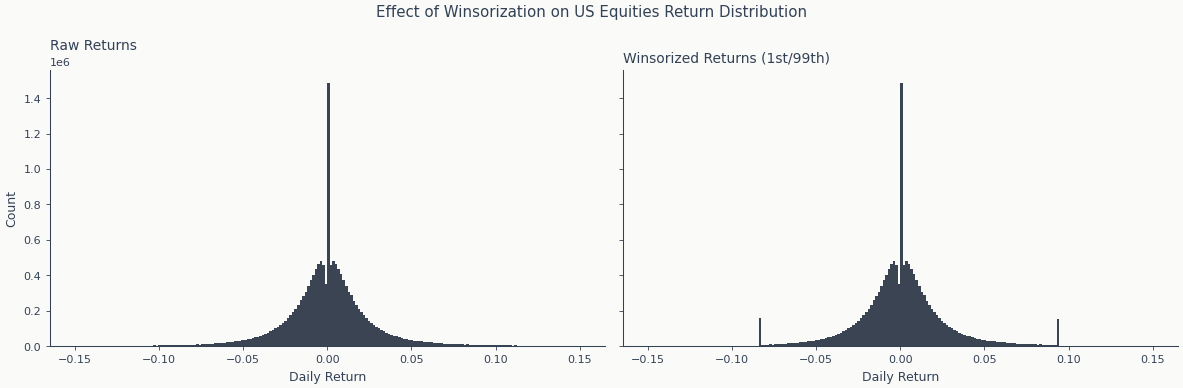

In [17]:
if us_equities is not None:
    raw_returns = us_equities_cleaned["returns"].drop_nulls().to_numpy()
    winsorized = winsorize_panel(
        us_equities_cleaned.filter(pl.col("returns").is_not_null()),
        fields=["returns"],
        limits=(0.01, 0.99),
        by_period=False,
    )["returns"].to_numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    bin_edges = np.linspace(-0.15, 0.15, 201)
    axes[0].hist(raw_returns, bins=bin_edges, alpha=0.8)
    axes[0].set_title("Raw Returns")
    axes[0].set_xlabel("Daily Return")
    axes[0].set_ylabel("Count")

    axes[1].hist(winsorized, bins=bin_edges, alpha=0.8)
    axes[1].set_title("Winsorized Returns (1st/99th)")
    axes[1].set_xlabel("Daily Return")

    fig.suptitle("Effect of Winsorization on US Equities Return Distribution")
    fig.tight_layout()
    fig.show()

Winsorization clips the extreme tails without distorting the bulk of the
distribution. The 1st/99th percentile bounds remove genuine outliers while
preserving the fat-tailed shape that characterizes equity returns.

### Cleaned US Equities Summary

The cleaning pipeline is a teaching demonstration — downstream case study
notebooks apply their own cleaning via loaders and feature engineering.

In [18]:
if us_equities is not None:
    save_cols = [
        c for c in us_equities_cleaned.columns if c not in ["returns", "is_spike", "is_gap"]
    ]
    cleaned = us_equities_cleaned.select(save_cols)
    print(f"Cleaned US Equities: {len(cleaned):,} rows, {cleaned['symbol'].n_unique()} symbols")
    print(f"Date range: {cleaned['timestamp'].min()} to {cleaned['timestamp'].max()}")

Cleaned US Equities: 15,160,868 rows, 3199 symbols
Date range: 1970-01-02 to 2018-03-27


## 4. ETF Universe Cleanup

Yahoo Finance data has specific issues: adjustment artifacts from splits
and distributions, ticker changes, and occasional data gaps.

In [19]:
etfs = None
try:
    etfs = ensure_symbol_alias(load_etfs())
    if "timestamp" in etfs.columns:
        etfs = etfs.with_columns(pl.col("timestamp").dt.date().alias("timestamp"))
    etfs = filter_from_start(etfs, "timestamp", ETF_START_DATE)
    print(f"Loaded {len(etfs):,} rows, {etfs['symbol'].n_unique()} symbols")
except Exception as e:
    print(f"Could not load ETFs: {type(e).__name__}")

Loaded 275,536 rows, 100 symbols


In [20]:
if etfs is not None:
    original_rows = len(etfs)

    # Detect overnight jumps matching common split ratios
    etfs_sorted = etfs.sort(["symbol", "timestamp"]).with_columns(
        overnight_return=(pl.col("open") / pl.col("close").shift(1).over("symbol") - 1)
    )
    split_ratios = [0.5, 0.333, 0.25, 2.0, 3.0, 4.0]
    tolerance = 0.01
    potential_issues = etfs_sorted.filter(
        pl.any_horizontal(
            [(pl.col("overnight_return") - (ratio - 1)).abs() < tolerance for ratio in split_ratios]
        )
    )
    print(f"Adjustment artifacts: {len(potential_issues)} potential split-like jumps")

    # Domain filters
    domain_rules = {
        "positive_prices": lambda _: pl.col("close") > 0,
        "non_negative_volume": lambda _: pl.col("volume") >= 0,
    }
    etfs_cleaned, removed_counts = apply_domain_filters(etfs_sorted, domain_rules)
    for rule, count in removed_counts.items():
        if count > 0:
            print(f"{rule}: removed {count:,} rows")

    # Gap check
    etfs_cleaned = fill_expected_gaps(
        etfs_cleaned, "timestamp", "symbol", method="flag_only", max_gap_days=5
    )
    n_gaps = etfs_cleaned["is_gap"].sum()
    print(f"Unexpected gaps (>5 days): {n_gaps}")
    print(
        f"Final: {len(etfs_cleaned):,} rows ({100 * len(etfs_cleaned) / original_rows:.1f}% retained)"
    )

    etfs_cleaned = etfs_cleaned.drop(["overnight_return"])

Adjustment artifacts: 0 potential split-like jumps
Unexpected gaps (>5 days): 0
Final: 275,536 rows (100.0% retained)


In [21]:
if etfs is not None:
    save_cols = [c for c in etfs_cleaned.columns if c not in ["is_gap"]]
    cleaned = etfs_cleaned.select(save_cols)
    print(f"Cleaned ETFs: {len(cleaned):,} rows, {cleaned['symbol'].n_unique()} symbols")
    print(f"Date range: {cleaned['timestamp'].min()} to {cleaned['timestamp'].max()}")

Cleaned ETFs: 275,536 rows, 100 symbols
Date range: 2015-01-02 to 2025-12-31


ETF cleaning is lighter than US Equities because the universe is curated
(100 liquid ETFs). The main concerns are adjustment artifacts from Yahoo
Finance and occasional data gaps around holidays or ticker changes.

## 5. Cross-Dataset Alignment Demo

When combining datasets with different frequencies (daily equities with
monthly characteristics, or 8-hour crypto bars), alignment must preserve
point-in-time correctness.

### 5.1 Crypto Spot + Perps Alignment

Aligning 8-hour bars for basis computation: the premium index
captures the funding rate differential between spot and perpetual futures.

In [22]:
crypto_perps = None
crypto_premium = None

try:
    crypto_perps = ensure_symbol_alias(load_crypto_perps(frequency="8h"))
    crypto_premium = ensure_symbol_alias(load_crypto_premium(frequency="8h"))
    crypto_perps = filter_from_start(crypto_perps, "timestamp", CRYPTO_START_DATE)
    crypto_premium = filter_from_start(crypto_premium, "timestamp", CRYPTO_START_DATE)
    print(f"Perps: {len(crypto_perps):,} rows | Premium: {len(crypto_premium):,} rows")
except Exception as e:
    print(f"Could not load crypto data: {type(e).__name__}")

Perps: 97,717 rows | Premium: 97,239 rows


In [23]:
if crypto_perps is not None and crypto_premium is not None:
    aligned = crypto_perps.join(
        crypto_premium.select(
            ["timestamp", "symbol", pl.col("premium_index_close").alias("premium")]
        ),
        on=["timestamp", "symbol"],
        how="inner",
    )
    aligned = aligned.with_columns(basis=pl.col("premium") * 100)

    print(f"Aligned: {len(aligned):,} rows, {aligned['symbol'].n_unique()} symbols")
    display(aligned.select("basis").describe())

Aligned: 97,179 rows, 19 symbols


statistic,basis
str,f64
"""count""",97179.0
"""null_count""",0.0
"""mean""",-0.013974
"""std""",0.110737
"""min""",-19.154743
"""25%""",-0.051824
"""50%""",-0.022179
"""75%""",0.001284
"""max""",1.270094


The inner join ensures we only keep timestamps where both datasets have
observations. The basis (premium × 100) converts the raw premium index
to percentage points for readability.

### 5.2 Equity + Firm Characteristics As-Of Join

Monthly characteristics must be joined to daily prices using point-in-time
logic: each daily observation gets the most recent monthly snapshot.

In [24]:
firm_char = None
try:
    firm_char = load_firm_characteristics()
    firm_char = firm_char.filter(
        pl.col("timestamp") >= datetime.fromisoformat(FIRM_CHARACTERISTICS_START_DATE)
    )
    print(f"Firm chars: {len(firm_char):,} rows, {len(firm_char.columns)} columns")
except Exception as e:
    print(f"Could not load firm characteristics: {type(e).__name__}")

Firm chars: 804,530 rows, 49 columns


In [25]:
if firm_char is not None:
    char_cols = sorted(c for c in firm_char.columns if c not in ["timestamp", "split", "ret"])[:5]
    split_counts = firm_char.group_by("split").agg(pl.len().alias("n_obs")).sort("split")
    display(split_counts)
    print(f"Sample characteristics: {char_cols}")
    print(f"Date range: {firm_char['timestamp'].min()} to {firm_char['timestamp'].max()}")

split,n_obs
str,u32
"""test""",497436
"""valid""",307094


Sample characteristics: ['A2ME', 'AC', 'AT', 'ATO', 'BEME']
Date range: 1990-01-31 to 2016-12-30


The as-of join pattern for monthly characteristics:

```python
daily_df.with_columns(month=pl.col('timestamp').dt.truncate('1mo'))
daily_df.join(monthly_chars, left_on=['permno', 'month'], right_on=['permno', 'timestamp'])
```

This ensures each daily observation sees only information available at
that point in time, preventing lookahead from future characteristic updates.

## 6. Categorical Encoding Demo

Section 7.1 discusses categorical encodings (one-hot, ordinal, hashing).
The key constraint: **fit the encoder on training data only** so that
unseen categories in the test set are handled gracefully.

In [26]:
# Create sample data with a categorical field (NumPy RNG is seeded globally in the preamble)
n_samples = 500
sectors = ["Technology", "Finance", "Healthcare", "Energy", "Consumer"]
train_sectors = np.random.choice(sectors, size=n_samples)
test_sectors = np.random.choice(sectors + ["Utilities"], size=100)  # Unseen category

cat_train = pl.DataFrame({"sector": train_sectors, "returns": np.random.randn(n_samples) * 0.02})
cat_test = pl.DataFrame({"sector": test_sectors, "returns": np.random.randn(100) * 0.02})

print(f"Train sectors: {sorted(str(s) for s in set(train_sectors))}")
print(f"Test sectors:  {sorted(str(s) for s in set(test_sectors))}")

Train sectors: ['Consumer', 'Energy', 'Finance', 'Healthcare', 'Technology']
Test sectors:  ['Consumer', 'Energy', 'Finance', 'Healthcare', 'Technology', 'Utilities']


In [27]:
# Fit encoder on training data only
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoder.fit(cat_train.select("sector").to_pandas())

# Transform both splits
train_encoded = encoder.transform(cat_train.select("sector").to_pandas())
test_encoded = encoder.transform(cat_test.select("sector").to_pandas())

print(f"Encoded columns: {encoder.get_feature_names_out().tolist()}")
print(f"Train shape: {train_encoded.shape}")
print(f"Test shape:  {test_encoded.shape}")

Encoded columns: ['sector_Consumer', 'sector_Energy', 'sector_Finance', 'sector_Healthcare', 'sector_Technology']
Train shape: (500, 5)
Test shape:  (100, 5)


In [28]:
# Show how unseen "Utilities" category is handled
utilities_mask = cat_test["sector"] == "Utilities"
n_utilities = utilities_mask.sum()
utilities_encoded = test_encoded[utilities_mask.to_numpy()]
print(f"\nUnseen 'Utilities' rows: {n_utilities}")
print(f"Encoding (all zeros): {utilities_encoded[0] if n_utilities > 0 else 'N/A'}")


Unseen 'Utilities' rows: 13
Encoding (all zeros): [0. 0. 0. 0. 0.]


The `handle_unknown="ignore"` setting maps unseen categories to all-zero
vectors. This is the correct behavior for split-aware encoding: the model
sees a neutral representation for categories it wasn't trained on, rather
than crashing or silently misencoding.

## 7. Split-Aware Preprocessing Demo

The critical lesson: **preprocessing parameters must be learned on training
data only**. Fitting on the full dataset leaks future information into the
training representation.

### 7.1 Correct Approach: Fit on Train Only

In [29]:
n_train, n_test = 1000, 200

sample_data = pl.DataFrame(
    {
        "timestamp": pl.date_range(datetime(2020, 1, 1), datetime(2023, 12, 31), eager=True)[
            : n_train + n_test
        ],
        "returns": np.random.randn(n_train + n_test) * 0.02,
        "volume": np.random.exponential(1e6, n_train + n_test),
    }
)

# Add regime-dependent extreme values (March = high volatility)
sample_data = sample_data.with_columns(
    returns=pl.when(pl.col("timestamp").dt.month() == 3)
    .then(pl.col("returns") * 3)
    .otherwise(pl.col("returns"))
)

train_df = sample_data.head(n_train)
test_df = sample_data.tail(n_test)
print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")

Train: 1000 rows | Test: 200 rows


In [30]:
preprocessor = SplitAwarePreprocessor(
    scale_cols=["returns"],
    winsorize_cols=["returns"],
    winsorize_limits=(0.01, 0.99),
)
preprocessor.fit(train_df)

train_processed = preprocessor.transform(train_df)
test_processed = preprocessor.transform(test_df)

print("Learned from training data:")
print(f"  Mean: {preprocessor._scale_params['returns']['mean']:.6f}")
print(f"  Std:  {preprocessor._scale_params['returns']['std']:.6f}")
print(
    f"  Winsorize: [{preprocessor._winsorize_params['returns']['lower']:.4f}, "
    f"{preprocessor._winsorize_params['returns']['upper']:.4f}]"
)
print(
    f"\nTrain processed: mean={train_processed['returns'].mean():.4f}, "
    f"std={train_processed['returns'].std():.4f}"
)
print(
    f"Test processed:  mean={test_processed['returns'].mean():.4f}, "
    f"std={test_processed['returns'].std():.4f}"
)

Learned from training data:
  Mean: 0.000768
  Std:  0.026290
  Winsorize: [-0.0670, 0.0717]

Train processed: mean=0.0026, std=0.8885
Test processed:  mean=0.0720, std=1.0271


The test set mean and standard deviation differ from 0 and 1 because the
scaler uses training-period parameters. This is correct behavior: the
test set represents unseen future data with potentially different statistics.

### 7.2 WRONG Approach: Fit on Full Data (Leakage Demo)

What happens when we cheat and fit on all data including the test set?

In [31]:
full_data = pl.concat([train_df, test_df])
leaky_preprocessor = SplitAwarePreprocessor(scale_cols=["returns"])
leaky_preprocessor.fit(full_data)  # BUG: includes future data!

correct_mean = preprocessor._scale_params["returns"]["mean"]
leaky_mean = leaky_preprocessor._scale_params["returns"]["mean"]
correct_std = preprocessor._scale_params["returns"]["std"]
leaky_std = leaky_preprocessor._scale_params["returns"]["std"]

print(
    f"Correct mean: {correct_mean:.6f} | Leaky mean: {leaky_mean:.6f} | Diff: {abs(correct_mean - leaky_mean):.6f}"
)
print(
    f"Correct std:  {correct_std:.6f} | Leaky std:  {leaky_std:.6f} | Diff: {abs(correct_std - leaky_std):.6f}"
)

# Transform test set with leaky parameters for comparison
leaky_test_processed = leaky_preprocessor.transform(test_df)

Correct mean: 0.000768 | Leaky mean: 0.001217 | Diff: 0.000449
Correct std:  0.026290 | Leaky std:  0.027230 | Diff: 0.000940


The parameter differences appear small in this synthetic example. But across
dozens of features and thousands of test observations, the cumulative effect
of leaking future information can meaningfully inflate apparent performance.
More fundamentally, it violates the train/test boundary that gives evaluation
its meaning.

### Leakage comparison figure

Visualize how the two scaling approaches produce different test-set distributions.

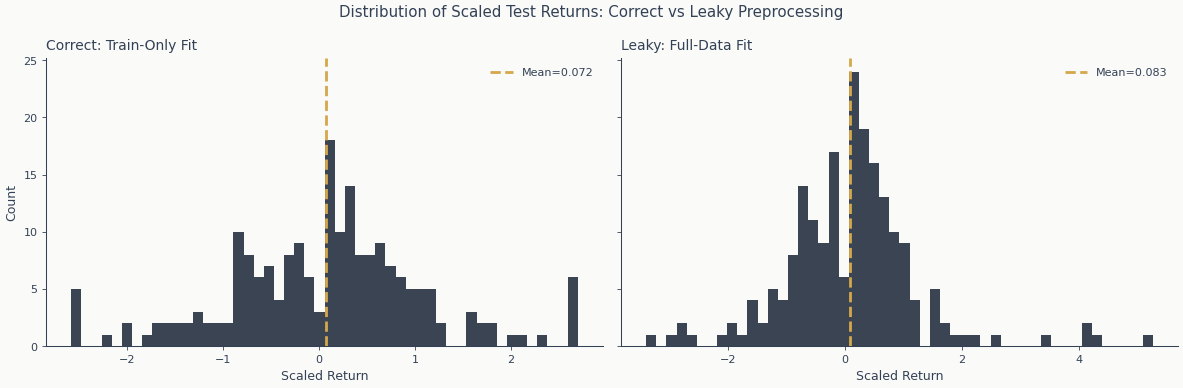

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

correct_vals = test_processed["returns"].to_numpy()
leaky_vals = leaky_test_processed["returns"].to_numpy()

axes[0].hist(correct_vals, bins=np.linspace(correct_vals.min(), correct_vals.max(), 51), alpha=0.8)
axes[0].axvline(
    correct_vals.mean(),
    color="C1",
    linestyle="--",
    linewidth=2,
    label=f"Mean={correct_vals.mean():.3f}",
)
axes[0].set_title("Correct: Train-Only Fit")
axes[0].set_xlabel("Scaled Return")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(leaky_vals, bins=np.linspace(leaky_vals.min(), leaky_vals.max(), 51), alpha=0.8)
axes[1].axvline(
    leaky_vals.mean(),
    color="C1",
    linestyle="--",
    linewidth=2,
    label=f"Mean={leaky_vals.mean():.3f}",
)
axes[1].set_title("Leaky: Full-Data Fit")
axes[1].set_xlabel("Scaled Return")
axes[1].legend()

fig.suptitle("Distribution of Scaled Test Returns: Correct vs Leaky Preprocessing")
fig.tight_layout()
fig.show()

The location and scale shifts between the two panels demonstrate information
leakage. In production with many features, this systematic bias accumulates
and can meaningfully inflate Sharpe ratios and IC estimates.

### 7.3 Walk-Forward Refit Demo

In walk-forward evaluation (Chapter 6), the preprocessor must be **refit
at each fold boundary** using only data available up to that point.
Parameters drift over time as the data distribution evolves.

In [33]:
# Simple 3-fold walk-forward loop
fold_size = len(sample_data) // 4
folds = [
    (sample_data[:fold_size], sample_data[fold_size : 2 * fold_size]),
    (sample_data[: 2 * fold_size], sample_data[2 * fold_size : 3 * fold_size]),
    (sample_data[: 3 * fold_size], sample_data[3 * fold_size :]),
]

fold_rows = []
for i, (fold_train, fold_test) in enumerate(folds, 1):
    fold_pp = SplitAwarePreprocessor(
        scale_cols=["returns"],
        winsorize_cols=["returns"],
        winsorize_limits=(0.01, 0.99),
    )
    fold_pp.fit(fold_train)
    params = fold_pp._scale_params["returns"]
    wparams = fold_pp._winsorize_params["returns"]
    fold_rows.append(
        {
            "fold": i,
            "n_train": len(fold_train),
            "n_test": len(fold_test),
            "mean": round(params["mean"], 6),
            "std": round(params["std"], 6),
            "winsor_lo": round(wparams["lower"], 4),
            "winsor_hi": round(wparams["upper"], 4),
        }
    )

fold_summary = pl.DataFrame(fold_rows)
fold_summary

fold,n_train,n_test,mean,std,winsor_lo,winsor_hi
i64,i64,i64,f64,f64,f64,f64
1,300,300,0.003546,0.02998,-0.0807,0.0906
2,600,300,0.001783,0.028172,-0.0807,0.0746
3,900,300,0.001148,0.027003,-0.0766,0.072


Parameters vary across folds as the expanding training window incorporates
new periods. The variation here is small because the synthetic data is
stationary by construction; in real markets, regime shifts produce larger
swings in mean, variance, and tail bounds. The walk-forward protocol ensures
each test fold sees parameters estimated only from its past, so any drift
(small or large) is handled correctly.

### 7.4 Preprocessor Serialization Demo

Demonstrate save/load round-trip. Note: `pickle` is used here for
simplicity. For production systems, prefer `ml4t-engineer` serialization.

In [34]:
with tempfile.NamedTemporaryFile(suffix=".pkl", delete=True) as tmp:
    preprocessor.save(tmp.name)
    loaded_preprocessor = SplitAwarePreprocessor.load(tmp.name)
    print(f"Round-trip OK: fitted={loaded_preprocessor._fitted}")
    print(f"  Scale params: {loaded_preprocessor._scale_params}")

Round-trip OK: fitted=True
  Scale params: {'returns': {'mean': 0.0007676845036926392, 'std': 0.026290177923298144}}


### 7.5 Production Alternative: ml4t-engineer

The manual `SplitAwarePreprocessor` above teaches the principle. In
practice, use the tested library version which provides the same
split-aware semantics with better performance and serialization.

In [35]:
# Compare manual scale-only (no winsorization) against library
manual_scale_only = SplitAwarePreprocessor(scale_cols=["returns"])
manual_scale_only.fit(train_df)
manual_test_scaled = manual_scale_only.transform(test_df)

lib_scaler = StandardScaler(columns=["returns"])
train_lib = lib_scaler.fit_transform(train_df)
test_lib = lib_scaler.transform(test_df)

print(
    f"Library scaler (train): mean={train_lib['returns'].mean():.4f}, std={train_lib['returns'].std():.4f}"
)
print(
    f"Library scaler (test):  mean={test_lib['returns'].mean():.4f}, std={test_lib['returns'].std():.4f}"
)

manual_test_mean = manual_test_scaled["returns"].mean()
lib_test_mean = test_lib["returns"].mean()
print(f"\nManual vs library difference: {abs(manual_test_mean - lib_test_mean):.6f}")

Library scaler (train): mean=-0.0000, std=1.0000
Library scaler (test):  mean=0.1026, std=1.1978

Manual vs library difference: 0.000000


Comparing the manual scaler (without winsorization) against the library
implementation confirms they produce consistent results. Any small
differences reflect implementation details in standard deviation computation
(sample vs population).

## 8. Final Verification

Quick quality check on the cleaned data (in-memory, not persisted).

In [36]:
for name, df in [("US Equities", us_equities_cleaned), ("ETFs", etfs_cleaned)]:
    if df is not None:
        null_close = df["close"].is_null().sum()
        neg_close = (df["close"] < 0).sum()
        print(
            f"{name}: {len(df):,} rows, {df['symbol'].n_unique()} symbols, "
            f"null_close={null_close}, neg_close={neg_close}"
        )

US Equities: 15,160,868 rows, 3199 symbols, null_close=0, neg_close=0
ETFs: 275,536 rows, 100 symbols, null_close=0, neg_close=0


Both cleaned datasets pass basic quality checks: no null or negative
prices remain. This notebook demonstrates the cleaning techniques —
downstream case study notebooks apply their own cleaning via loaders.

## Key Takeaways

1. **Preprocessing must be split-aware** — fit parameters on training data only
2. **Domain filters catch obvious errors** — negative prices, impossible OHLC relations
3. **Spike detection identifies data artifacts** — single-bar reversals often indicate errors
4. **Winsorization handles outliers** — but bounds must come from training data
5. **Categorical encoding** must handle unseen categories at test time
6. **Walk-forward refit** captures parameter drift across market regimes
7. **Cross-dataset alignment requires care** — use as-of joins for different frequencies

**Next**: See `05_signal_evaluation` for IC-based signal quality assessment.
**Book**: Section 7.1 discusses why preprocessing choices affect model validity.